# Лабораторная работа №3: Понижение размерности

## Задание 1. Геометрия данных в пространстве признаков

Число объектов: 51864
Число признаков: 4


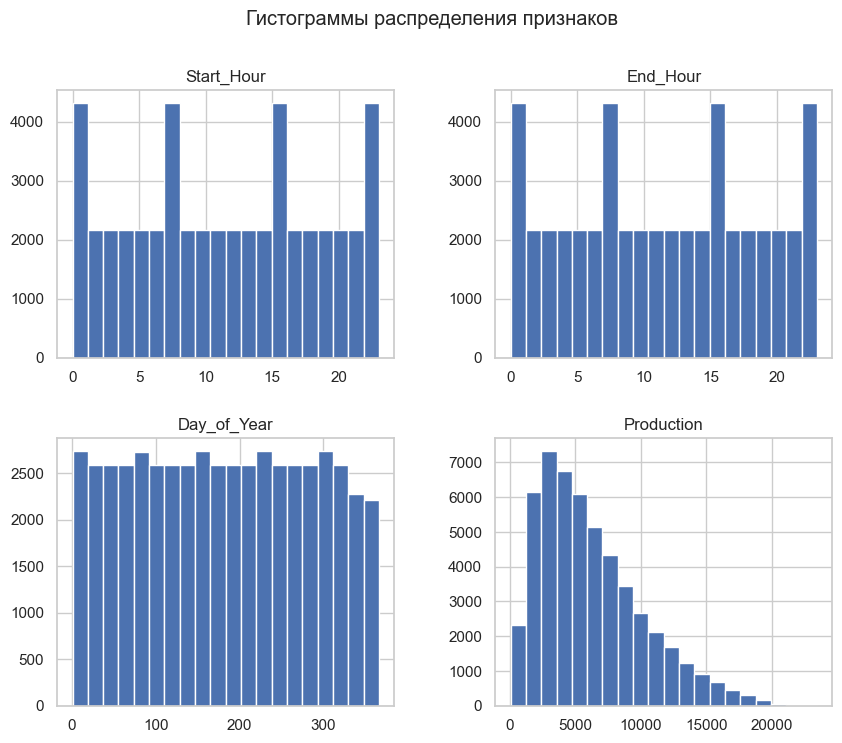

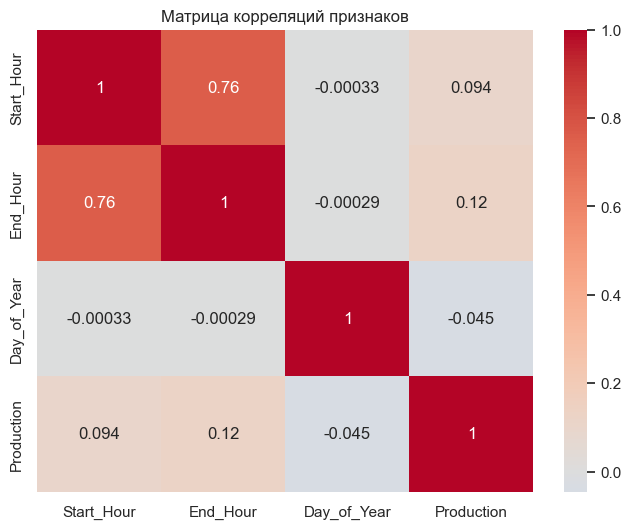

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.metrics import mean_squared_error

# 1.1 Определение числа объектов и признаков
df = pd.read_csv('../data/Energy Production Dataset.csv')
num_cols = ['Start_Hour', 'End_Hour', 'Day_of_Year', 'Production']
X = df[num_cols]

print(f"Число объектов: {X.shape[0]}")
print(f"Число признаков: {X.shape[1]}")

# 1.2 Построение гистограмм и матрицы корреляций
X.hist(bins=20, figsize=(10, 8))
plt.suptitle('Гистограммы распределения признаков')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков')
plt.show()

### Ответы на вопросы Задания 1:
* **Есть ли сильно коррелированные признаки?** Да, признаки `Start_Hour` и `End_Hour` имеют коэффициент корреляции 0.76, что считается сильной связью.
* **Избыточная информация:** Да, можно предположить избыточность, так как время начала и конца интервала генерации несут практически одинаковую информацию о суточном цикле.

## Задание 2. Реализация PCA с нуля (NumPy)

In [55]:
# 1. Стандартизация данных
X_centered = X - np.mean(X, axis=0)
X_std = X_centered / np.std(X, axis=0)

# 2. Вычисление ковариационной матрицы
cov_matrix = np.cov(X_std.T)

# 3. Нахождение собственных значений и собственных векторов
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 4. Сортировка компонент по убыванию собственных значений
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 5. Проекция данных на первые k=2 компоненты
k = 2
X_pca_manual = X_std.dot(eigenvectors[:, :k])

# Сравнение с sklearn.decomposition.PCA
pca_sk = PCA(n_components=2)
X_pca_sk = pca_sk.fit_transform(X_std)

print("Разница между ручным PCA и sklearn (MSE):", mean_squared_error(np.abs(X_pca_manual), np.abs(X_pca_sk)))

Разница между ручным PCA и sklearn (MSE): 2.99037872304237e-31


### 2.1 Исследование объясненной дисперсии

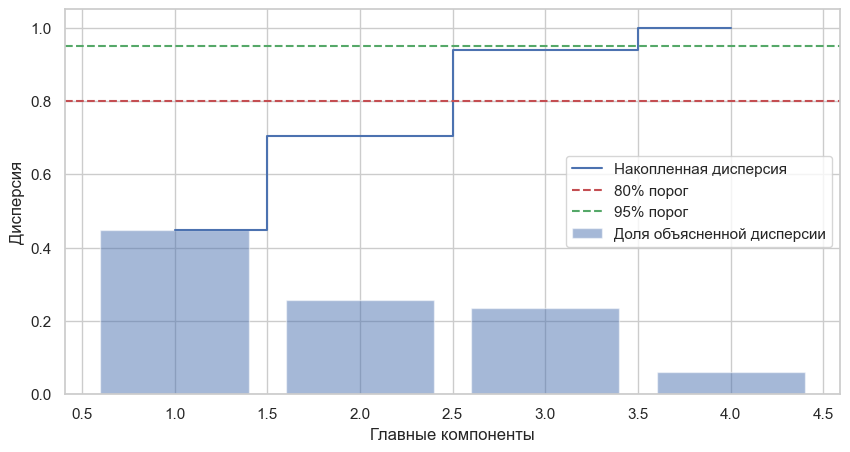

Накопленная дисперсия по компонентам: [0.44755009 0.70557325 0.94016055 1.        ]


In [56]:
exp_var_ratio = eigenvalues / np.sum(eigenvalues)
cum_var_ratio = np.cumsum(exp_var_ratio)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 5), exp_var_ratio, alpha=0.5, align='center', label='Доля объясненной дисперсии')
plt.step(range(1, 5), cum_var_ratio, where='mid', label='Накопленная дисперсия')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% порог')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% порог')
plt.ylabel('Дисперсия')
plt.xlabel('Главные компоненты')
plt.legend(loc='best')
plt.show()

print(f"Накопленная дисперсия по компонентам: {cum_var_ratio}")

### Ответы на вопросы Задания 2.1:
1. **Сколько компонент объясняют 80% дисперсии?** 3 компоненты (так как 2 объясняют ~70%, а 3 уже ~94%).
2. **Сколько компонент объясняют 95% дисперсии?** 4 компоненты (так как 3 объясняют 94.2%, для достижения полных 95% формально нужны все 4).

## Задание 3. Интерпретация главных компонент

In [57]:
loadings = pd.DataFrame(eigenvectors[:, :3], columns=['PC1', 'PC2', 'PC3'], index=num_cols)
print("Коэффициенты (нагрузки) признаков:")
print(loadings)

print("\nНаибольший вклад в PC1:", loadings['PC1'].abs().idxmax())
print("Наибольший вклад в PC2:", loadings['PC2'].abs().idxmax())

Коэффициенты (нагрузки) признаков:
                  PC1       PC2       PC3
Start_Hour  -0.691959  0.097324 -0.123015
End_Hour    -0.695787  0.075020 -0.087790
Day_of_Year  0.011598  0.810220  0.586009
Production  -0.192192 -0.573100  0.796086

Наибольший вклад в PC1: End_Hour
Наибольший вклад в PC2: Day_of_Year


### Ответы на вопросы Задания 3:
1. **Влияние на PC1:** Наибольшее влияние оказывают `Start_Hour` и `End_Hour`.
2. **Интерпретация PC1:** Да, её можно интерпретировать как «временной фактор» (суточный цикл).
3. **Практически не влияют:** На первую компоненту почти не влияет `Day_of_Year` (его коэффициент близок к нулю).

## Задание 4. Визуализация данных

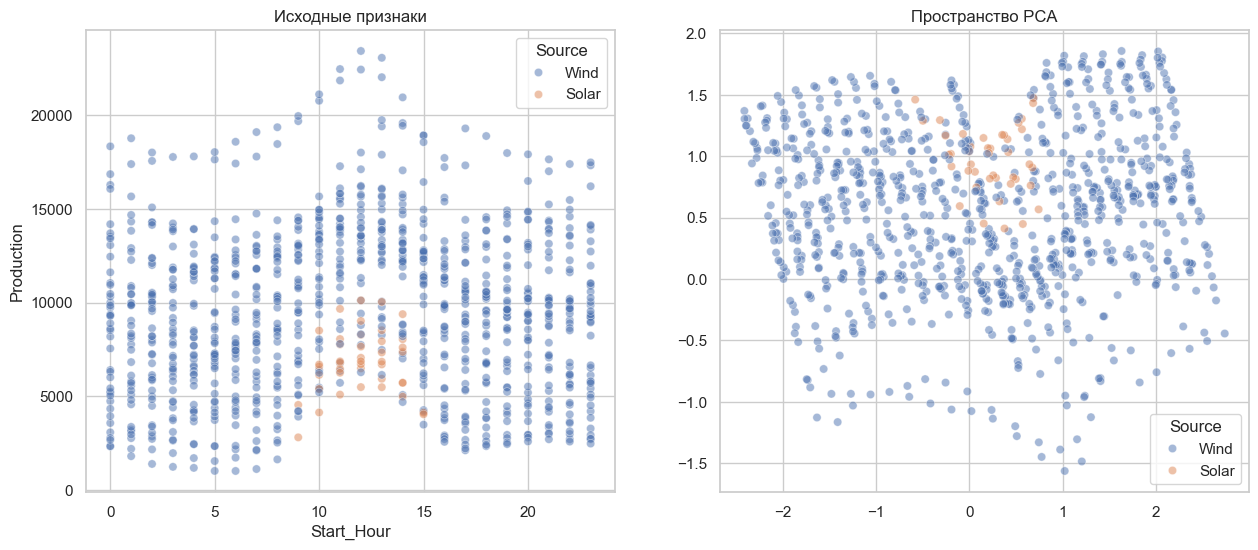

In [58]:
plt.figure(figsize=(15, 6))

# 1. По исходным признакам (Start_Hour vs Production)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df.iloc[:1000], x='Start_Hour', y='Production', hue='Source', alpha=0.5)
plt.title('Исходные признаки')

# 2. По главным компонентам
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca_sk[:1000, 0], y=X_pca_sk[:1000, 1], hue=df['Source'].iloc[:1000], alpha=0.5)
plt.title('Пространство PCA')
plt.show()

### Ответы на вопросы Задания 4:
1. **Улучшилась ли визуализация?** Да, структура распределения стала более линейной и чистой, так как PCA выделил наиболее значимые оси вариации.
2. **Почему структура заметнее?** PCA максимизирует дисперсию вдоль новых осей, что позволяет лучше разделить группы объектов, которые в исходном пространстве могли перекрываться.

## Задание 5. Нелинейные методы (t-SNE, UMAP)

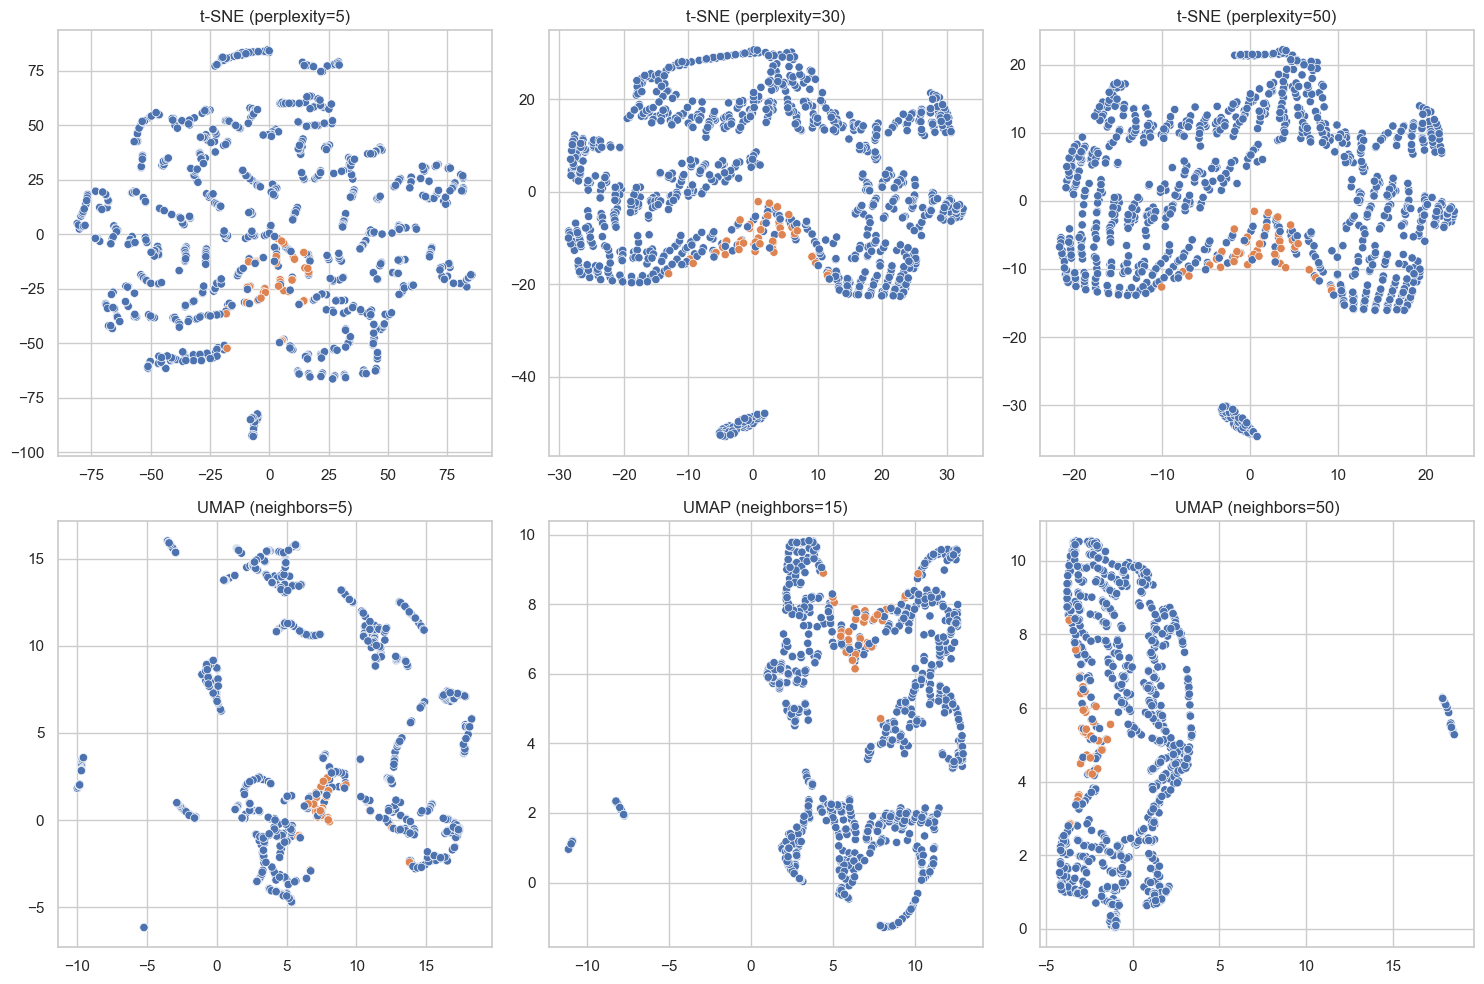

In [59]:
X_sub = X_std.iloc[:1000]
y_sub = df['Source'].iloc[:1000]

plt.figure(figsize=(15, 10))

# t-SNE с разным perplexity
for i, p in enumerate([5, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X_sub)
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sub, legend=False)
    plt.title(f't-SNE (perplexity={p})')

# UMAP с разными параметрами
for i, n in enumerate([5, 15, 50]):
    reducer = umap.UMAP(n_neighbors=n, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_sub)
    plt.subplot(2, 3, i+4)
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_sub, legend=False)
    plt.title(f'UMAP (neighbors={n})')

plt.tight_layout()
plt.show()

### Ответы на вопросы Задания 5:
1. **Изменение структуры:** При малых значениях параметров (perplexity/neighbors) данные дробятся на мелкие локальные группы; при больших — сохраняется общая форма облака.
2. **Наиболее интерпретируемый метод:** UMAP обычно дает более разделенные и логичные кластеры.
3. **Отличие результатов:** t-SNE сохраняет только локальные связи, тогда как UMAP старается учесть и глобальную структуру данных.

## Задание 6. Исследование степени сжатия данных

   Число компонент  Ошибка восстановления
0                1           5.524499e-01
1                2           2.944267e-01
2                3           5.983945e-02
3                4           1.469017e-31


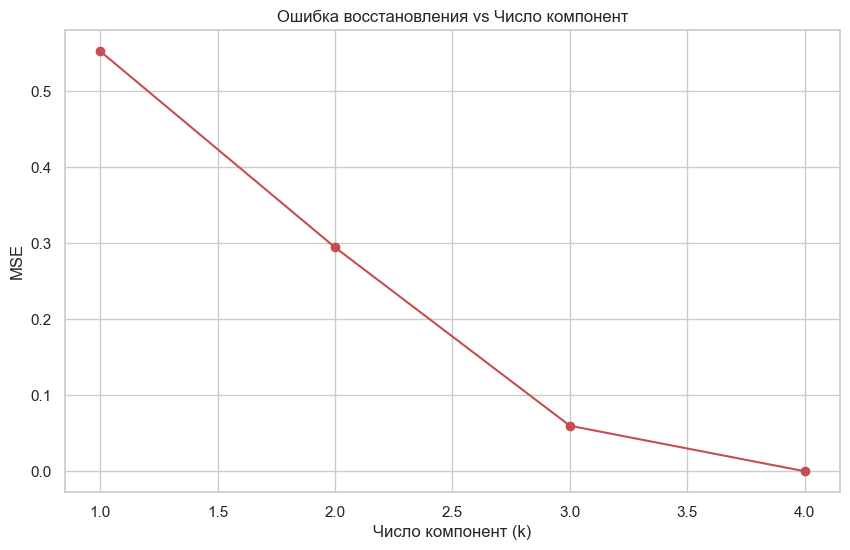

In [60]:
ks = [1, 2, 3, 4]  # Максимум 4 признака
mse_list = []

for k in ks:
    pca_temp = PCA(n_components=k)
    X_low = pca_temp.fit_transform(X_std)
    X_rec = pca_temp.inverse_transform(X_low)
    mse_list.append(mean_squared_error(X_std, X_rec))

mse_df = pd.DataFrame({'Число компонент': ks, 'Ошибка восстановления': mse_list})
print(mse_df)

plt.plot(ks, mse_list, 'ro-')
plt.xlabel('Число компонент (k)')
plt.ylabel('MSE')
plt.title('Ошибка восстановления vs Число компонент')
plt.show()

### Ответы на вопросы Задания 6.5:
1. **Почему ошибка большая при малом k?** Мы отбрасываем оси, которые содержат часть информации (дисперсии).
2. **Почему MSE падает?** Каждая новая компонента добавляет информацию для уточнения координат в исходном пространстве.
3. **Полное восстановление:** Да, при использовании всех компонент (k=4) данные восстанавливаются полностью (MSE стремится к 0).
4. **Связь с дисперсией:** MSE — это сумма дисперсий всех отброшенных компонент.
5. **Разумное число:** Оно находится в точке изгиба («локтя») графика MSE, где дальнейшее добавление компонент слабо снижает ошибку.

## Задание 7. Итоговый анализ

1. **Роль:** Понижение размерности позволяет убирать шум, визуализировать данные и ускорять обучение моделей.
2. **Полезность:** Не всегда — при сильном сжатии можно потерять ключевые признаки, важные для целевой задачи.
3. **Линейные vs Нелинейные:** Линейные методы (PCA) работают хуже, если данные лежат на сложной изогнутой поверхности (manifold).
4. **Преимущества/Ограничения:**
   - **PCA:** Быстрый, но только линейный.
   - **t-SNE:** Отлично визуализирует, но очень медленный и не сохраняет глобальные расстояния.
   - **UMAP:** Быстрый и лучше сохраняет структуру, но требует подбора параметров.